## Model Building

In this notebook, we train a machine learning model to predict the Air Quality Index (AQI) using environmental pollutant features. Before training the model, the dataset is split into training and testing sets to evaluate its performance on unseen data.

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df=pd.read_csv("../data/processed/AQI_processed_data.csv")
df.head()

,datetime,AQI,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3
0,1970-01-01 00:00:01.783731600,3,67.63,0.00,0.68,38.67,0.74,14.64,61.21,0.24
1,1970-01-01 00:00:01.783735200,3,68.75,0.01,0.88,38.99,0.81,14.09,58.51,0.25
2,1970-01-01 00:00:01.783738800,3,70.31,0.06,1.07,40.05,0.90,13.57,55.94,0.23
3,1970-01-01 00:00:01.783742400,3,71.19,0.12,1.03,43.18,0.95,13.26,55.49,0.20
4,1970-01-01 00:00:01.783746000,3,71.06,0.14,0.80,47.91,0.95,12.99,53.78,0.18


In [4]:
df["datetime"]=pd.to_datetime(df["datetime"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  115 non-null    datetime64[ns]
 1   AQI       115 non-null    int64         
 2   CO        115 non-null    float64       
 3   NO        115 non-null    float64       
 4   NO2       115 non-null    float64       
 5   O3        115 non-null    float64       
 6   SO2       115 non-null    float64       
 7   PM2_5     115 non-null    float64       
 8   PM10      115 non-null    float64       
 9   NH3       115 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 9.1 KB


In [12]:
X=df.drop(columns=["AQI", "datetime"])
y=df["AQI"]

In [6]:
print("feature:",X.shape)
print("target",y.shape)

feature: (115, 9)
target (115,)


## Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data.

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [14]:
print(X_train.dtypes)

CO       float64
NO       float64
NO2      float64
O3       float64
SO2      float64
PM2_5    float64
PM10     float64
NH3      float64
dtype: object


In [15]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 92 entries, 31 to 102
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CO      92 non-null     float64
 1   NO      92 non-null     float64
 2   NO2     92 non-null     float64
 3   O3      92 non-null     float64
 4   SO2     92 non-null     float64
 5   PM2_5   92 non-null     float64
 6   PM10    92 non-null     float64
 7   NH3     92 non-null     float64
dtypes: float64(8)
memory usage: 6.5 KB


## Random Forest Model Training

In this step, a Random Forest Regressor is trained using the training dataset to predict Air Quality Index (AQI).

In [16]:
# Create the Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,   # Number of decision trees in the forest
    random_state=42     # Ensures reproducible results
)

# Train the model using the training data
model.fit(X_train, y_train)

# Display a confirmation message
print("Model trained successfully.")

Model trained successfully.


In [17]:
y_pred = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.055652173913043466
RMSE: 0.14252383477250696
R² Score: 0.9739184466019417


In [19]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)


  Feature  Importance
6    PM10    0.701791
5   PM2_5    0.289532
7     NH3    0.008677
0      CO    0.000000
3      O3    0.000000
2     NO2    0.000000
1      NO    0.000000
4     SO2    0.000000


In [20]:
import joblib

joblib.dump(model, "../models/random_forest_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [21]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.055652173913043466
MSE : 0.020313043478260864
RMSE: 0.14252383477250696
R2 Score: 0.9739184466019417


## Model Evaluation

In this section, the trained Random Forest model is evaluated using standard regression metrics. These metrics help measure prediction error and overall model performance.

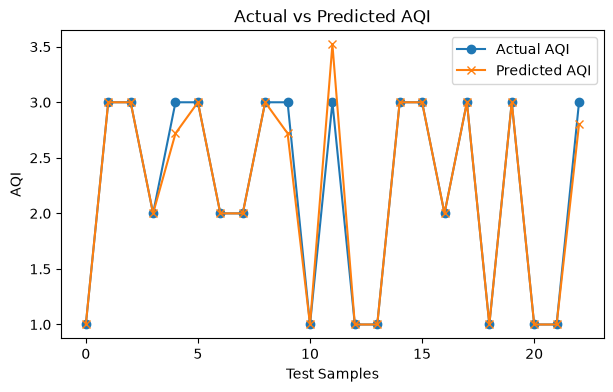

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(y_test.values, label="Actual AQI", marker="o")
plt.plot(y_pred, label="Predicted AQI", marker="x")

plt.title("Actual vs Predicted AQI")
plt.xlabel("Test Samples")
plt.ylabel("AQI")

plt.legend()

plt.show()

## Feature Importance

This analysis shows which environmental pollutants contribute the most to AQI prediction according to the Random Forest model.

  Feature  Importance
6    PM10    0.701791
5   PM2_5    0.289532
7     NH3    0.008677
0      CO    0.000000
3      O3    0.000000
2     NO2    0.000000
1      NO    0.000000
4     SO2    0.000000


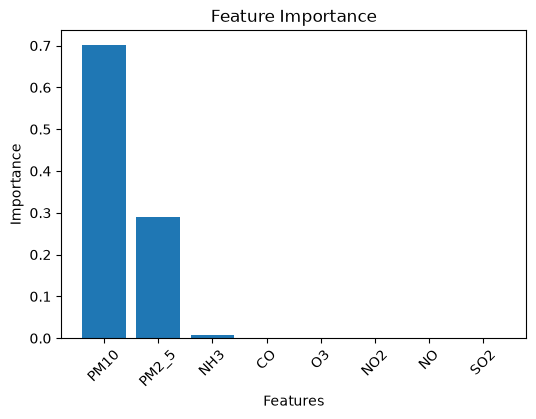

In [25]:

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

plt.figure(figsize=(6,4))
plt.bar(importance["Feature"], importance["Importance"])

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [27]:
print(X.columns.tolist())

['CO', 'NO', 'NO2', 'O3', 'SO2', 'PM2_5', 'PM10', 'NH3']
